# Illustrate double-well potential and double-well flow
ISHII Hidemasa

In [1]:
using Random, CairoMakie
import ColorSchemes as cs

In [2]:
potential(x, r) = x^4 / 4 - (1 + r) / 3 * x^3 + r / 2 * x^2;
flow(x, r) = -x * (x - r) * (x - 1);

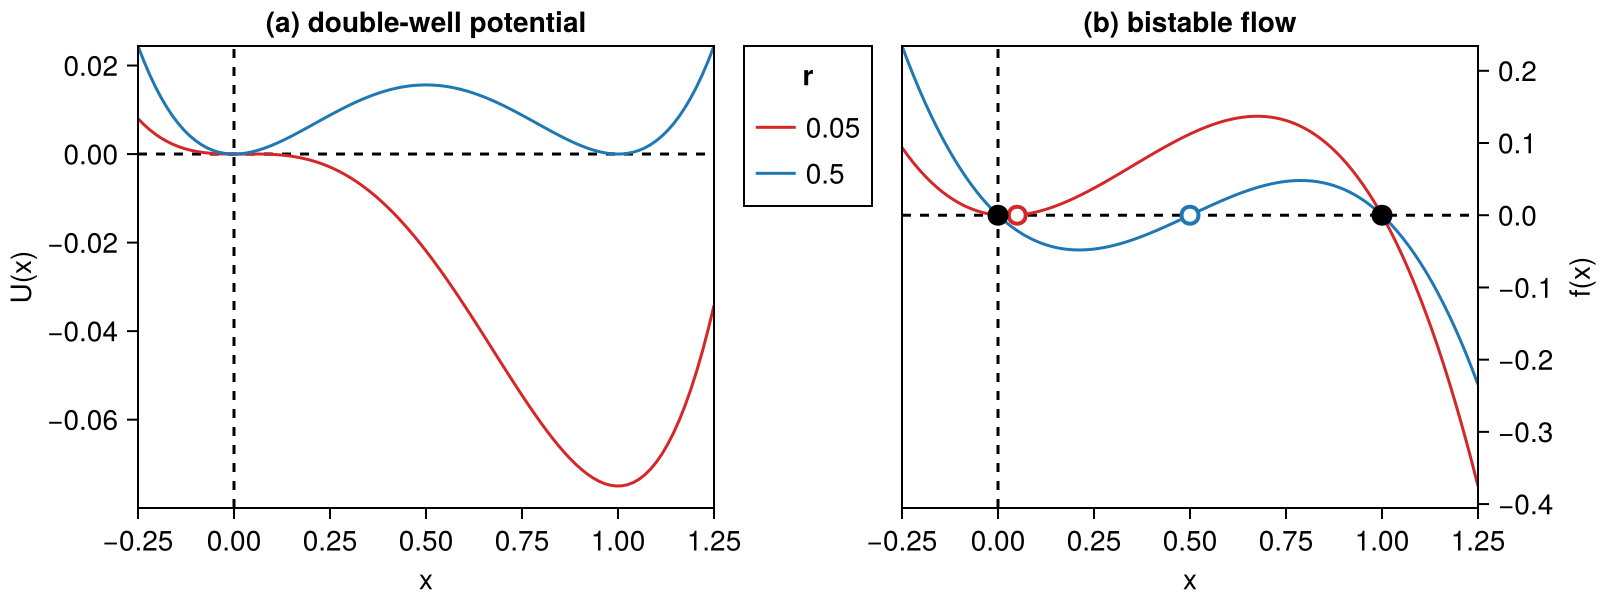

In [6]:
let plt = cs.tab10[[4, 1]], ifsave = true
    fig = Figure(size=(800, 300), figure_padding=3)
    axopts = (xlabel="x", xgridvisible=false, xautolimitmargin=(0, 0), 
        ygridvisible=false, yautolimitmargin=(0.05, 0),
    )
    ax1 = Axis(fig[1, 1]; title="(a) double-well potential", ylabel="U(x)", axopts...)
    ax2 = Axis(fig[1, 3]; title="(b) bistable flow", 
        ylabel="f(x)", yaxisposition=:right,
        axopts...
    )

    for ax in (ax1, ax2)
        hlines!(ax, 0, color=:black, linestyle=:dash)
        vlines!(ax, 0, color=:black, linestyle=:dash)
    end

    x = collect(range(-0.25, 1.25, 101))
    rvals = [0.05, 0.5]
    ms, sw = (12, 2)
    for (j, r) in enumerate(rvals)
        lines!(ax1, x, potential.(x, r), color=plt[j], label="$r")
        lines!(ax2, x, flow.(x, r), color=plt[j], label="$r")
        scatter!(ax2, [r,], [0,], 
            markersize=ms, color=:white, strokecolor=plt[j], strokewidth=sw
        )
    end
    scatter!(ax2, [0, 1], [0, 0], color=:black, markersize=ms, strokewidth=sw)

    colgap!(fig.layout, 15)
    Legend(fig[1, 2], ax1, "r"; valign=:top)

    if ifsave save("output/fig-1d-bistability.pdf", fig) end
    display(fig)
end;

## images for Introduction

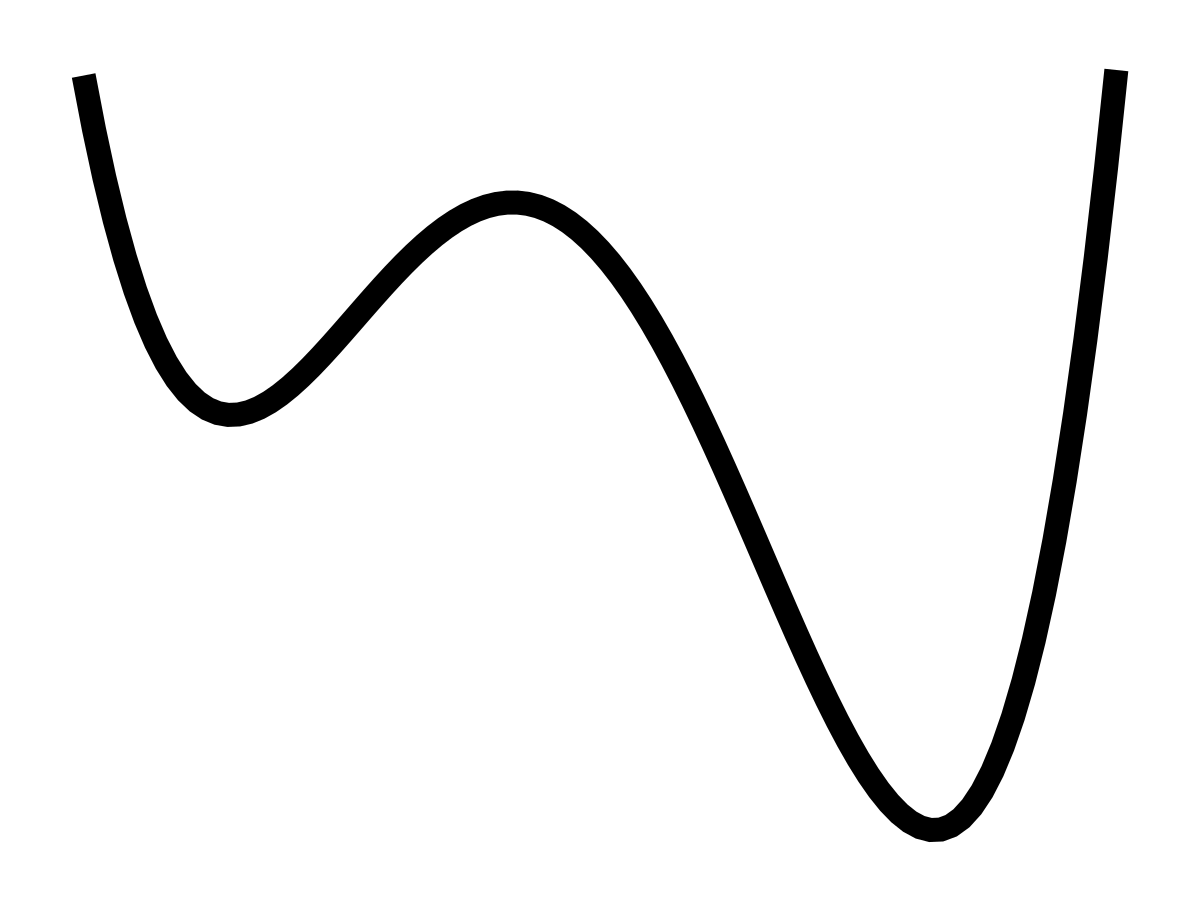

In [4]:
let r = 0.4, ifsave = true
    fig = Figure()
    ax = Axis(fig[1, 1])
    hidedecorations!(ax)
    hidespines!(ax)

    x = collect(range(-0.21, 1.259, 101))
    lines!(ax, x, potential.(x, r), color=:black, linewidth=12)
    
    if ifsave save("output/fig-dwpot-only.png", fig) end
    display(fig)
end;

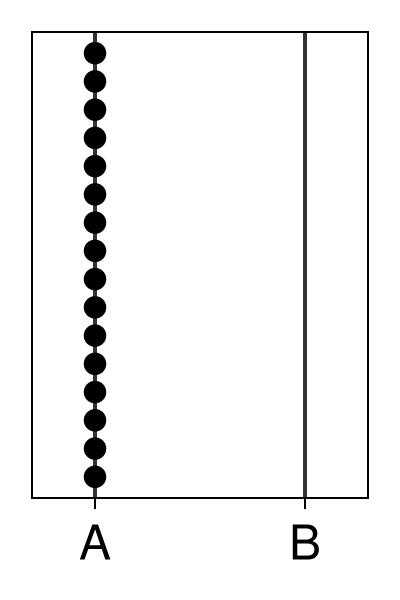

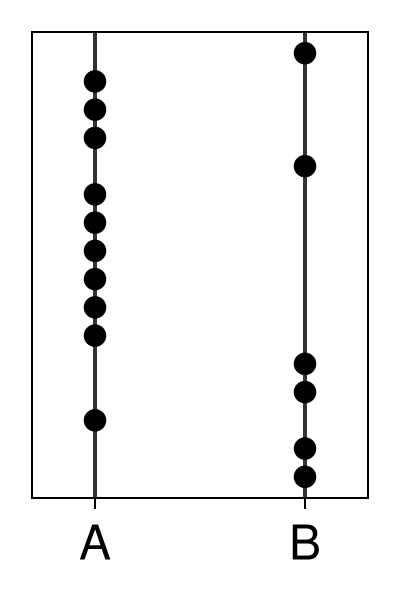

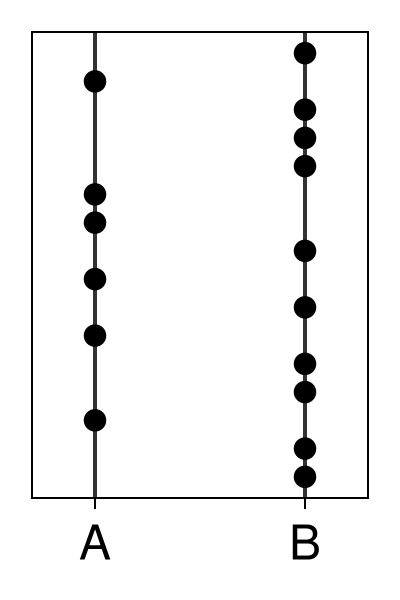

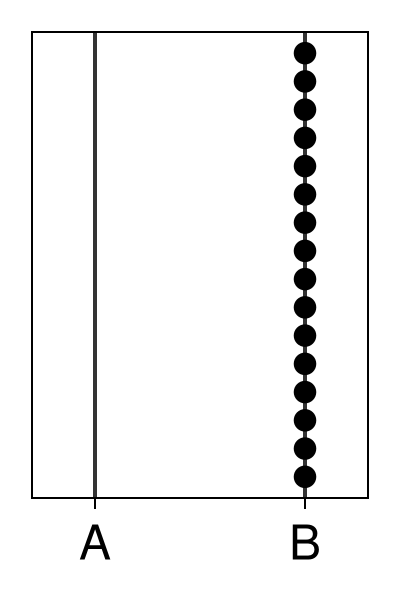

In [5]:
let N = 16, steps = 4, rng = Xoshiro(1028), ifsave = true
    state = zeros(Bool, N)

    for i in 1:steps
        # update states
        if i == steps
            state .|= ones(Bool, N)
        elseif i >= 2
            state .|= bitrand(rng, N)
        end

        fig = Figure(size=(200, 300))
        ax = Axis(fig[1, 1]; xticks=([0, 1], ["A", "B"]), 
            xticklabelsize=24, xautolimitmargin=(0.3, 0.3)
        )
        hidexdecorations!(ax; ticks=false, ticklabels=false)
        hideydecorations!(ax)

        vlines!(ax, [0, 1], color=:gray20, linewidth=2)
        scatter!(ax, state, collect(1:N), color=:black, markersize=16)

        if ifsave save("output/fig-seq-escape-$i.png", fig) end
        display(fig)
    end
end